# Intrinsic Hardness vs Model Hardness on Nonsmooth Nonconvex SOCP

This notebook studies four linked questions on the `nonsmooth_nonconvex/socp` benchmark:

1. Which instances are intrinsically hard as optimization problems?
2. Which instances are hard for `FSNet` and `penalty` ensembles?
3. Are those the same instances, or only partially overlapping?
4. Why does ensembling help, and do different members specialize on different subsets?

The notebook uses:

- the saved dataset and oracle solutions from `random2025_socp_dataset_var100_ineq50_eq50_ex10000`,
- the saved 5-member `FSNet` and `penalty` ensemble runs for seeds `0`, `100`, and `2025`,
- the existing evaluation machinery in the repo.

No IPOPT replay is used in this v1 notebook; intrinsic hardness is defined from the saved dataset and generator structure only.

In [20]:
import os
import sys
import math
import json
import pickle
import textwrap

import numpy as np
import torch
import matplotlib.pyplot as plt

sys.path.insert(0, os.getcwd())

from eval import resolve_checkpoints, load_single_model
from utils.trainer import load_instance, DEVICE
from utils.evaluator import Evaluator

plt.rcParams['figure.figsize'] = (8, 5)
plt.rcParams['axes.grid'] = True
np.set_printoptions(precision=4, suppress=True)


def print_table(headers, rows, floatfmt='{:.4e}', max_rows=None):
    rows = list(rows)
    if max_rows is not None:
        rows = rows[:max_rows]

    formatted = []
    for row in rows:
        out = []
        for val in row:
            if isinstance(val, (float, np.floating)):
                out.append(floatfmt.format(float(val)))
            else:
                out.append(str(val))
        formatted.append(out)

    widths = [len(str(h)) for h in headers]
    for row in formatted:
        for i, val in enumerate(row):
            widths[i] = max(widths[i], len(val))

    header_line = ' | '.join(str(h).ljust(widths[i]) for i, h in enumerate(headers))
    sep_line = '-+-'.join('-' * widths[i] for i in range(len(headers)))
    print(header_line)
    print(sep_line)
    for row in formatted:
        print(' | '.join(row[i].ljust(widths[i]) for i in range(len(headers))))


def simple_rank(x):
    x = np.asarray(x)
    order = np.argsort(x, kind='mergesort')
    ranks = np.empty_like(order, dtype=float)
    ranks[order] = np.arange(len(x), dtype=float)
    return ranks


def spearman_corr(a, b):
    a = np.asarray(a, dtype=float)
    b = np.asarray(b, dtype=float)
    mask = np.isfinite(a) & np.isfinite(b)
    if mask.sum() < 3:
        return np.nan
    ra = simple_rank(a[mask])
    rb = simple_rank(b[mask])
    sa = ra.std()
    sb = rb.std()
    if sa < 1e-12 or sb < 1e-12:
        return np.nan
    return float(np.corrcoef(ra, rb)[0, 1])


def pearson_corr(a, b):
    a = np.asarray(a, dtype=float)
    b = np.asarray(b, dtype=float)
    mask = np.isfinite(a) & np.isfinite(b)
    if mask.sum() < 3:
        return np.nan
    aa = a[mask]
    bb = b[mask]
    if aa.std() < 1e-12 or bb.std() < 1e-12:
        return np.nan
    return float(np.corrcoef(aa, bb)[0, 1])


def qcut_mask(x, q=0.9, hard=True):
    thr = np.quantile(x, q)
    if hard:
        return x >= thr
    thr = np.quantile(x, 1.0 - q)
    return x <= thr


def safe_mean(x):
    x = np.asarray(x)
    return float(np.mean(x)) if len(x) else np.nan


def jaccard(a_mask, b_mask):
    inter = np.logical_and(a_mask, b_mask).sum()
    union = np.logical_or(a_mask, b_mask).sum()
    return float(inter / union) if union else np.nan


def overlap_frac(a_mask, b_mask):
    denom = a_mask.sum()
    return float(np.logical_and(a_mask, b_mask).sum() / denom) if denom else np.nan


def entropy_from_counts(counts):
    counts = np.asarray(counts, dtype=float)
    probs = counts[counts > 0] / counts.sum()
    if len(probs) == 0:
        return 0.0
    return float(-(probs * np.log2(probs)).sum())


## 1. Configuration

In [21]:
DATASET_PATH = 'datasets/nonsmooth_nonconvex/socp/random2025_socp_dataset_var100_ineq50_eq50_ex10000'

RUN_GROUPS = {
    'FSNet': {
        0: 'results/nonsmooth_nonconvex/socp/SOCPProblem-100-50-50-10000/20260315-172824_FSNet_seed0_e300_lr1e-04_n7000_ens5_vanilla_pre',
        100: 'results/nonsmooth_nonconvex/socp/SOCPProblem-100-50-50-10000/20260315-174003_FSNet_seed100_e300_lr1e-04_n7000_ens5_vanilla_pre',
        2025: 'results/nonsmooth_nonconvex/socp/SOCPProblem-100-50-50-10000/20260316-003057_FSNet_seed2025_e300_lr1e-04_n7000_ens5_vanilla_pre',
    },
    'penalty': {
        0: 'results/nonsmooth_nonconvex/socp/SOCPProblem-100-50-50-10000/20260316-003102_penalty_seed0_e1000_lr1e-04_n7000_ens5_vanilla_pre',
        100: 'results/nonsmooth_nonconvex/socp/SOCPProblem-100-50-50-10000/20260316-004753_penalty_seed100_e1000_lr1e-04_n7000_ens5_vanilla_pre',
        2025: 'results/nonsmooth_nonconvex/socp/SOCPProblem-100-50-50-10000/20260316-010442_penalty_seed2025_e1000_lr1e-04_n7000_ens5_vanilla_pre',
    },
}

TRAIN_SIZE = 7000
VAL_SIZE = 1000
TEST_SIZE = 2000
TEST_SLICE = slice(TRAIN_SIZE + VAL_SIZE, TRAIN_SIZE + VAL_SIZE + TEST_SIZE)

BATCH_SIZE = 256
MERIT_EQ_WEIGHT = 1e5
MERIT_INEQ_WEIGHT = 1e5

ACTIVE_TOL = 5e-2
BOUND_TOL = 2.5e-1
TOPK_ACTIVE_FOR_JAC = 5
HARD_Q = 0.90

print('Configured run groups:')
for method, seeds in RUN_GROUPS.items():
    for seed, run_dir in seeds.items():
        print(f'  {method:8s} seed={seed:4d} -> {run_dir}')


Configured run groups:
  FSNet    seed=   0 -> results/nonsmooth_nonconvex/socp/SOCPProblem-100-50-50-10000/20260315-172824_FSNet_seed0_e300_lr1e-04_n7000_ens5_vanilla_pre
  FSNet    seed= 100 -> results/nonsmooth_nonconvex/socp/SOCPProblem-100-50-50-10000/20260315-174003_FSNet_seed100_e300_lr1e-04_n7000_ens5_vanilla_pre
  FSNet    seed=2025 -> results/nonsmooth_nonconvex/socp/SOCPProblem-100-50-50-10000/20260316-003057_FSNet_seed2025_e300_lr1e-04_n7000_ens5_vanilla_pre
  penalty  seed=   0 -> results/nonsmooth_nonconvex/socp/SOCPProblem-100-50-50-10000/20260316-003102_penalty_seed0_e1000_lr1e-04_n7000_ens5_vanilla_pre
  penalty  seed= 100 -> results/nonsmooth_nonconvex/socp/SOCPProblem-100-50-50-10000/20260316-004753_penalty_seed100_e1000_lr1e-04_n7000_ens5_vanilla_pre
  penalty  seed=2025 -> results/nonsmooth_nonconvex/socp/SOCPProblem-100-50-50-10000/20260316-010442_penalty_seed2025_e1000_lr1e-04_n7000_ens5_vanilla_pre


## 2. Load dataset and align the shared test split

In [22]:
with open(DATASET_PATH, 'rb') as f:
    dataset = pickle.load(f)

first_fsnet_run = RUN_GROUPS['FSNet'][0]
first_ckpt = torch.load(resolve_checkpoints(first_fsnet_run)[0], map_location='cpu', weights_only=False)
base_config = dict(first_ckpt['config'])
base_config['_eval_only'] = True

opt_problem, _ = load_instance(base_config)

X_test_t, Y_test_t = opt_problem.test_dataset.tensors
X_test = X_test_t.detach().cpu().numpy()
Y_oracle = Y_test_t.detach().cpu().numpy()

Q = np.asarray(dataset['Q'])
p = np.asarray(dataset['p'])
A = np.asarray(dataset['A'])
G = np.asarray(dataset['G'])
h = np.asarray(dataset['h'])
C = np.asarray(dataset['C'])
d = np.asarray(dataset['d'])
YL = np.asarray(dataset['YL'])
YU = np.asarray(dataset['YU'])
best_partial = np.asarray(dataset['best_partial'])
other_vars = np.setdiff1d(np.arange(Y_oracle.shape[1]), best_partial)
A_other = A[:, other_vars]
A_other_svals = np.linalg.svd(A_other, compute_uv=False)
A_other_cond = float(A_other_svals[0] / max(A_other_svals[-1], 1e-12))

print(f'Loaded dataset keys: {sorted(dataset.keys())}')
print(f'X test shape: {X_test.shape}')
print(f'Y oracle shape: {Y_oracle.shape}')
print(f'Device used by evaluator runs: {DEVICE}')
print(f'Condition proxy for A[:, other_vars]: {A_other_cond:.4e}')

assert X_test.shape[0] == TEST_SIZE
assert Y_oracle.shape[0] == TEST_SIZE


Loaded dataset keys: ['A', 'C', 'G', 'Q', 'X', 'XL', 'XU', 'Y', 'YL', 'YU', 'best_partial', 'd', 'h', 'p']
X test shape: (2000, 50)
Y oracle shape: (2000, 100)
Device used by evaluator runs: cpu
Condition proxy for A[:, other_vars]: 2.9635e+01


## 3. Compute intrinsic hardness features from the dataset and oracle solution

These features use only the saved dataset and oracle `Y`, not any trained model.

In [23]:
def oracle_objective_np(Y):
    quad = 0.5 * np.sum((Y @ Q) * Y, axis=1)
    nonlin = np.sum(p[None, :] * np.sin(Y), axis=1)
    nonsmooth = 0.1 * np.linalg.norm(Y, axis=1)
    return quad + nonlin + nonsmooth + 20.0


def oracle_eq_abs_sum_np(X, Y):
    return np.abs(Y @ A.T - X).sum(axis=1)


def nonlinear_raw_and_grad_stats_for_instance(y):
    cos_y = np.cos(y)
    sin_y = np.sin(y)

    raw = np.zeros(G.shape[0], dtype=float)
    grad_norms = np.zeros(G.shape[0], dtype=float)
    grads = []

    for i in range(G.shape[0]):
        z = G[i] @ cos_y + h[i]
        z_norm = np.linalg.norm(z)
        raw[i] = z_norm - (C[i] @ y + d[i])
        direction = z / max(z_norm, 1e-12)
        grad = -(sin_y * (G[i].T @ direction)) - C[i]
        grads.append(grad)
        grad_norms[i] = np.linalg.norm(grad)

    return raw, np.asarray(grads), grad_norms


def build_intrinsic_features(X, Y):
    n = len(X)
    nonlinear_raw = np.zeros((n, G.shape[0]), dtype=float)
    nonlinear_grad_norm_mean = np.zeros(n, dtype=float)
    nonlinear_grad_norm_max = np.zeros(n, dtype=float)
    local_jacobian_cond = np.zeros(n, dtype=float)

    objective_nonlinearity = np.linalg.norm(p[None, :] * np.cos(Y), axis=1)
    x_norm2 = np.linalg.norm(X, axis=1)
    y_norm2 = np.linalg.norm(Y, axis=1)
    bound_slack = np.minimum(Y - YL[None, :], YU[None, :] - Y)
    min_bound_slack = bound_slack.min(axis=1)
    near_bound_count = (bound_slack < BOUND_TOL).sum(axis=1)

    for idx in range(n):
        raw_i, grads_i, grad_norms_i = nonlinear_raw_and_grad_stats_for_instance(Y[idx])
        nonlinear_raw[idx] = raw_i
        nonlinear_grad_norm_mean[idx] = grad_norms_i.mean()
        nonlinear_grad_norm_max[idx] = grad_norms_i.max()

        slacks_i = -raw_i
        active_like = np.where(slacks_i < ACTIVE_TOL)[0]
        if len(active_like) == 0:
            active_like = np.argsort(slacks_i)[:TOPK_ACTIVE_FOR_JAC]
        else:
            active_like = active_like[np.argsort(slacks_i[active_like])[:TOPK_ACTIVE_FOR_JAC]]

        J = np.vstack([A] + [grads_i[j] for j in active_like])
        svals = np.linalg.svd(J, compute_uv=False)
        local_jacobian_cond[idx] = svals[0] / max(svals[-1], 1e-12)

    nonlinear_slack = -nonlinear_raw
    min_nonlinear_slack = nonlinear_slack.min(axis=1)
    active_nonlinear_count = (nonlinear_slack < ACTIVE_TOL).sum(axis=1)

    feats = {
        'oracle_obj': oracle_objective_np(Y),
        'oracle_eq_abs': oracle_eq_abs_sum_np(X, Y),
        'oracle_ineq_violation': np.maximum(nonlinear_raw, 0.0).sum(axis=1),
        'x_norm2': x_norm2,
        'y_norm2': y_norm2,
        'min_nonlinear_slack': min_nonlinear_slack,
        'active_nonlinear_count': active_nonlinear_count.astype(float),
        'min_bound_slack': min_bound_slack,
        'near_bound_count': near_bound_count.astype(float),
        'objective_nonlinearity': objective_nonlinearity,
        'nonlinear_grad_norm_mean': nonlinear_grad_norm_mean,
        'nonlinear_grad_norm_max': nonlinear_grad_norm_max,
        'local_jacobian_cond': local_jacobian_cond,
    }

    score_parts = []
    harder_high = [
        'oracle_obj',
        'y_norm2',
        'active_nonlinear_count',
        'near_bound_count',
        'objective_nonlinearity',
        'nonlinear_grad_norm_mean',
        'local_jacobian_cond',
    ]
    harder_low = [
        'min_nonlinear_slack',
        'min_bound_slack',
    ]

    for name in harder_high:
        v = feats[name]
        score_parts.append((v - v.min()) / max(v.max() - v.min(), 1e-12))
    for name in harder_low:
        v = feats[name]
        inv = -v
        score_parts.append((inv - inv.min()) / max(inv.max() - inv.min(), 1e-12))

    feats['intrinsic_score'] = np.mean(score_parts, axis=0)
    feats['intrinsic_rank_score'] = np.mean([simple_rank(s) / max(len(s) - 1, 1) for s in score_parts], axis=0)
    return feats


intrinsic = build_intrinsic_features(X_test, Y_oracle)

sanity_rows = []
for name in ['oracle_obj', 'oracle_eq_abs', 'oracle_ineq_violation', 'min_nonlinear_slack', 'min_bound_slack', 'local_jacobian_cond', 'intrinsic_score']:
    vals = intrinsic[name]
    sanity_rows.append([name, vals.min(), np.median(vals), vals.mean(), np.quantile(vals, 0.9), vals.max()])

print('Intrinsic feature summary:')
print_table(['feature', 'min', 'median', 'mean', 'p90', 'max'], sanity_rows)

assert np.all(np.isfinite(intrinsic['intrinsic_score']))
print('\nSanity checks:')
print(f"  oracle_eq_abs mean = {intrinsic['oracle_eq_abs'].mean():.4e}")
print(f"  oracle_ineq_violation mean = {intrinsic['oracle_ineq_violation'].mean():.4e}")
print('  These should be near solver tolerance, not exactly zero.')


Intrinsic feature summary:
feature               | min         | median      | mean        | p90        | max       
----------------------+-------------+-------------+-------------+------------+-----------
oracle_obj            | 1.3503e+01  | 1.7109e+01  | 1.7589e+01  | 2.0573e+01 | 3.0745e+01
oracle_eq_abs         | 4.8394e-14  | 7.5199e-14  | 7.5840e-14  | 8.8537e-14 | 1.1187e-13
oracle_ineq_violation | 0.0000e+00  | 9.1597e-10  | 3.5020e-09  | 7.3111e-09 | 6.4170e-08
min_nonlinear_slack   | -8.4901e-09 | -8.1882e-10 | -7.0368e-10 | 3.2149e-09 | 1.0349e-08
min_bound_slack       | 1.9922e-01  | 2.5485e+00  | 2.2093e+00  | 2.9312e+00 | 3.1913e+00
local_jacobian_cond   | 5.4201e+00  | 6.7210e+00  | 6.8074e+00  | 7.6597e+00 | 1.1034e+01
intrinsic_score       | 1.8274e-01  | 3.4653e-01  | 3.4983e-01  | 4.3204e-01 | 5.9487e-01

Sanity checks:
  oracle_eq_abs mean = 7.5840e-14
  oracle_ineq_violation mean = 3.5020e-09
  These should be near solver tolerance, not exactly zero.


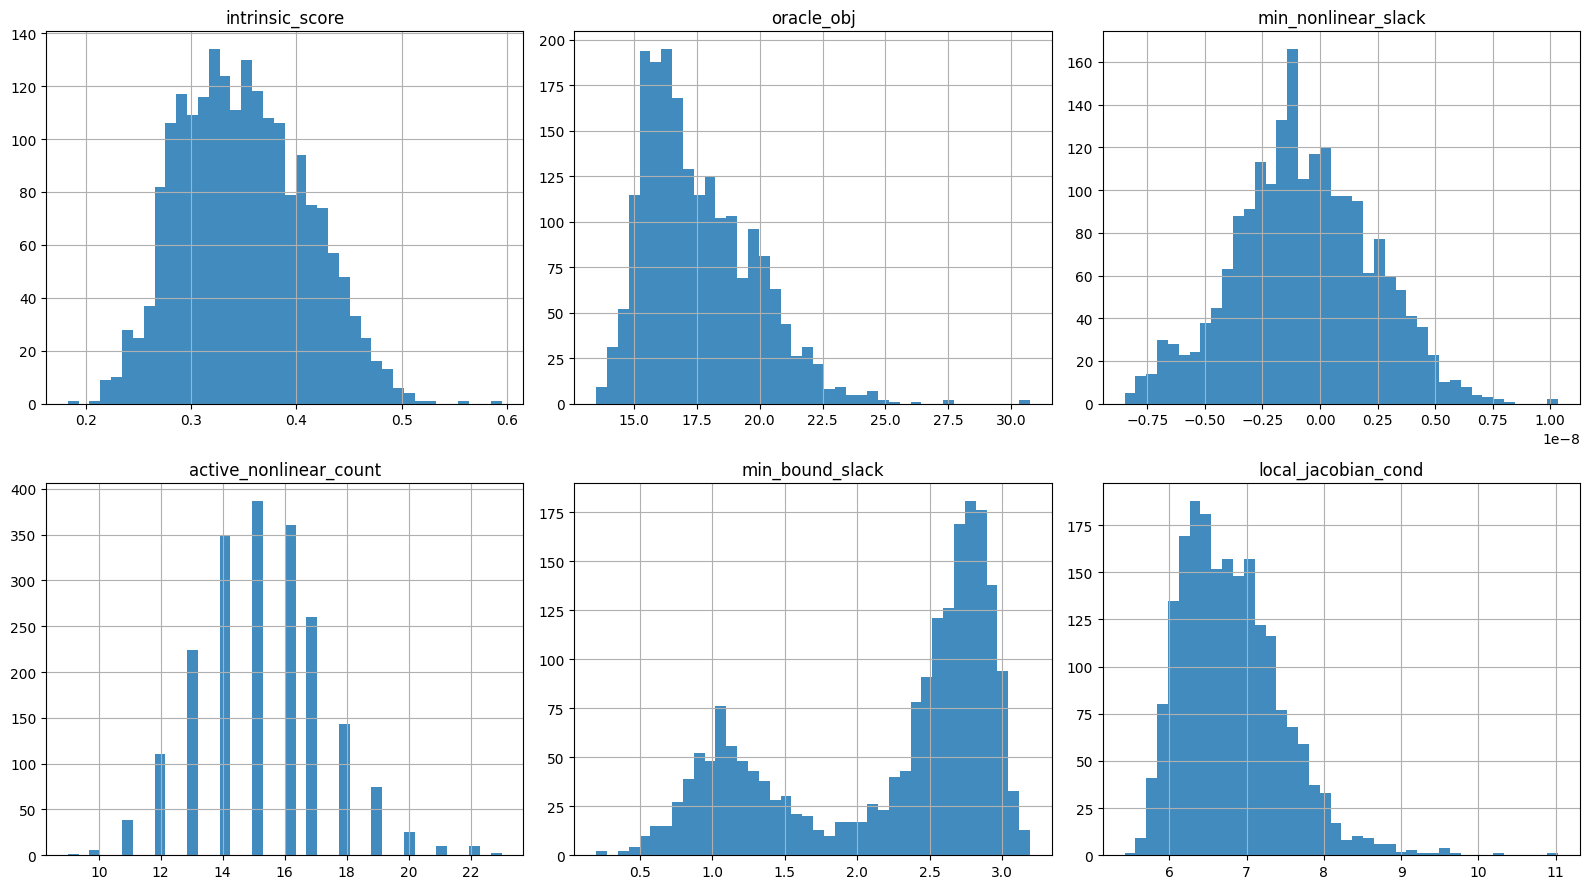

In [24]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
plot_names = [
    'intrinsic_score',
    'oracle_obj',
    'min_nonlinear_slack',
    'active_nonlinear_count',
    'min_bound_slack',
    'local_jacobian_cond',
]
for ax, name in zip(axes.ravel(), plot_names):
    ax.hist(intrinsic[name], bins=40, alpha=0.85)
    ax.set_title(name)
plt.tight_layout()
plt.show()


## 4. Evaluate all FSNet and penalty ensemble runs

In [25]:
def evaluate_member_run(model, evaluator, dataset, method, batch_size=256):
    loader = torch.utils.data.DataLoader(dataset, batch_size=batch_size, shuffle=False)
    out = {
        'raw_obj': [], 'raw_eq': [], 'raw_ineq': [], 'raw_merit': [],
        'final_obj': [], 'final_eq': [], 'final_ineq': [], 'final_merit': [],
        'move_l2': [], 'repair_gain': [],
    }

    for X_batch, _Y_true in loader:
        X_batch = X_batch.to(DEVICE)
        with torch.no_grad():
            Y_raw = model(X_batch)
            Y_raw_scaled = evaluator.opt_problem.scale(Y_raw)
            Y_final = evaluator._post_process_predictions(X_batch, Y_raw_scaled)

            raw_obj = evaluator.opt_problem.obj_fn(Y_raw_scaled)
            raw_eq = evaluator.opt_problem.eq_resid(X_batch, Y_raw_scaled).abs().sum(dim=1)
            raw_ineq = evaluator.opt_problem.ineq_resid(X_batch, Y_raw_scaled).abs().sum(dim=1)
            raw_merit = raw_obj + MERIT_EQ_WEIGHT * raw_eq + MERIT_INEQ_WEIGHT * raw_ineq

            final_obj = evaluator.opt_problem.obj_fn(Y_final)
            final_eq = evaluator.opt_problem.eq_resid(X_batch, Y_final).abs().sum(dim=1)
            final_ineq = evaluator.opt_problem.ineq_resid(X_batch, Y_final).abs().sum(dim=1)
            final_merit = final_obj + MERIT_EQ_WEIGHT * final_eq + MERIT_INEQ_WEIGHT * final_ineq

            move_l2 = torch.linalg.norm(Y_final - Y_raw_scaled, dim=1)
            repair_gain = raw_merit - final_merit

        for k, v in [
            ('raw_obj', raw_obj), ('raw_eq', raw_eq), ('raw_ineq', raw_ineq), ('raw_merit', raw_merit),
            ('final_obj', final_obj), ('final_eq', final_eq), ('final_ineq', final_ineq), ('final_merit', final_merit),
            ('move_l2', move_l2), ('repair_gain', repair_gain),
        ]:
            out[k].append(v.detach().cpu().numpy())

    return {k: np.concatenate(v) for k, v in out.items()}


def load_run_result(method, seed, run_dir):
    ckpts = resolve_checkpoints(run_dir)
    first = torch.load(ckpts[0], map_location='cpu', weights_only=False)
    cfg = dict(first['config'])
    cfg['ensemble_post'] = 'post'
    cfg['ensemble_agg'] = 'best_merit'
    cfg['_eval_only'] = True
    problem, _ = load_instance(cfg)
    evaluator = Evaluator(problem, method, cfg)

    member_out = []
    for i, ckpt in enumerate(ckpts):
        model, _ = load_single_model(ckpt, problem)
        model.eval()
        member_out.append(evaluate_member_run(model, evaluator, problem.test_dataset, method, batch_size=BATCH_SIZE))

    arrays = {name: np.stack([m[name] for m in member_out], axis=0) for name in member_out[0].keys()}
    winner = arrays['final_merit'].argmin(axis=0)
    sorted_merit = np.sort(arrays['final_merit'], axis=0)
    best_merit = arrays['final_merit'].min(axis=0)
    margin = sorted_merit[1] - sorted_merit[0]
    disagreement_std = arrays['final_merit'].std(axis=0)
    disagreement_range = arrays['final_merit'].max(axis=0) - arrays['final_merit'].min(axis=0)
    best_single_member = arrays['final_merit'].mean(axis=1).argmin()
    best_single_arr = arrays['final_merit'][best_single_member]
    ensemble_gain = best_single_arr - best_merit
    winner_move = arrays['move_l2'][winner, np.arange(len(winner))]
    winner_repair_gain = arrays['repair_gain'][winner, np.arange(len(winner))]

    return {
        'method': method,
        'seed': seed,
        'run_dir': run_dir,
        'member_arrays': arrays,
        'winner': winner,
        'best_merit': best_merit,
        'mean_member_merit': arrays['final_merit'].mean(axis=0),
        'margin': margin,
        'disagreement_std': disagreement_std,
        'disagreement_range': disagreement_range,
        'winner_move_l2': winner_move,
        'winner_repair_gain': winner_repair_gain,
        'best_single_member': int(best_single_member),
        'best_single_arr': best_single_arr,
        'ensemble_gain': ensemble_gain,
        'win_counts': np.bincount(winner, minlength=arrays['final_merit'].shape[0]),
    }


run_results = []
for method, seeds in RUN_GROUPS.items():
    for seed, run_dir in seeds.items():
        print(f'Loading/evaluating {method} seed={seed} ...')
        run_results.append(load_run_result(method, seed, run_dir))

print(f'\nFinished {len(run_results)} runs.')


Loading/evaluating FSNet seed=0 ...
Loading/evaluating FSNet seed=100 ...
Loading/evaluating FSNet seed=2025 ...
Loading/evaluating penalty seed=0 ...
Loading/evaluating penalty seed=100 ...
Loading/evaluating penalty seed=2025 ...

Finished 6 runs.


In [26]:
summary_rows = []
for rr in run_results:
    summary_rows.append([
        rr['method'],
        rr['seed'],
        rr['best_single_member'],
        rr['best_merit'].mean(),
        rr['best_single_arr'].mean(),
        rr['ensemble_gain'].mean(),
        rr['margin'].mean(),
        rr['disagreement_std'].mean(),
        entropy_from_counts(rr['win_counts']),
    ])

print('Run summary:')
print_table(
    ['method', 'seed', 'best_single_member', 'ens_mean_merit', 'best_single_mean', 'ens_gain', 'margin', 'disagree_std', 'winner_entropy'],
    summary_rows,
)


Run summary:
method  | seed | best_single_member | ens_mean_merit | best_single_mean | ens_gain   | margin     | disagree_std | winner_entropy
--------+------+--------------------+----------------+------------------+------------+------------+--------------+---------------
FSNet   | 0    | 0                  | 1.8796e+01     | 2.3051e+01       | 4.2546e+00 | 2.1503e+00 | 7.3665e+00   | 1.7821e+00    
FSNet   | 100  | 0                  | 1.8658e+01     | 2.3292e+01       | 4.6341e+00 | 2.3671e+00 | 8.1184e+00   | 1.5308e+00    
FSNet   | 2025 | 3                  | 1.7464e+01     | 2.1448e+01       | 3.9843e+00 | 1.8348e+00 | 1.8680e+01   | 1.1052e+00    
penalty | 0    | 3                  | 5.7243e+04     | 6.3936e+04       | 6.6935e+03 | 5.9970e+03 | 9.6008e+03   | 2.1165e+00    
penalty | 100  | 1                  | 5.8984e+04     | 6.6257e+04       | 7.2727e+03 | 5.9552e+03 | 9.6418e+03   | 2.1615e+00    
penalty | 2025 | 0                  | 5.8937e+04     | 6.4863e+04       | 5.9

## 5. Compare intrinsic hardness with model hardness

In [27]:
intrinsic_feature_names = [
    'intrinsic_score',
    'intrinsic_rank_score',
    'oracle_obj',
    'min_nonlinear_slack',
    'active_nonlinear_count',
    'min_bound_slack',
    'objective_nonlinearity',
    'local_jacobian_cond',
]

model_feature_specs = [
    ('best_merit', lambda rr: rr['best_merit']),
    ('margin', lambda rr: rr['margin']),
    ('disagreement_std', lambda rr: rr['disagreement_std']),
    ('disagreement_range', lambda rr: rr['disagreement_range']),
    ('ensemble_gain', lambda rr: rr['ensemble_gain']),
    ('winner_move_l2', lambda rr: rr['winner_move_l2']),
    ('winner_repair_gain', lambda rr: rr['winner_repair_gain']),
]

corr_rows = []
for rr in run_results:
    for ifeat in intrinsic_feature_names:
        for mname, getter in model_feature_specs:
            vals = getter(rr)
            corr_rows.append([
                rr['method'], rr['seed'], ifeat, mname,
                pearson_corr(intrinsic[ifeat], vals),
                spearman_corr(intrinsic[ifeat], vals),
            ])

print('Selected correlations (showing strongest absolute Spearman per run/model feature):')
for rr in run_results:
    rows = [r for r in corr_rows if r[0] == rr['method'] and r[1] == rr['seed']]
    for mname, _ in model_feature_specs:
        cand = [r for r in rows if r[3] == mname and np.isfinite(r[5])]
        if not cand:
            continue
        best = max(cand, key=lambda r: abs(r[5]))
        print(f"{rr['method']:8s} seed={rr['seed']:4d} {mname:18s} strongest intrinsic link -> {best[2]:22s} spearman={best[5]: .4f}")


Selected correlations (showing strongest absolute Spearman per run/model feature):
FSNet    seed=   0 best_merit         strongest intrinsic link -> oracle_obj             spearman= 0.1963
FSNet    seed=   0 margin             strongest intrinsic link -> min_nonlinear_slack    spearman=-0.0324
FSNet    seed=   0 disagreement_std   strongest intrinsic link -> oracle_obj             spearman= 0.0706
FSNet    seed=   0 disagreement_range strongest intrinsic link -> oracle_obj             spearman= 0.0648
FSNet    seed=   0 ensemble_gain      strongest intrinsic link -> intrinsic_rank_score   spearman= 0.0767
FSNet    seed=   0 winner_move_l2     strongest intrinsic link -> intrinsic_score        spearman=-0.0346
FSNet    seed=   0 winner_repair_gain strongest intrinsic link -> min_nonlinear_slack    spearman=-0.0383
FSNet    seed= 100 best_merit         strongest intrinsic link -> oracle_obj             spearman= 0.1876
FSNet    seed= 100 margin             strongest intrinsic link -> min

In [28]:
hard_mask = qcut_mask(intrinsic['intrinsic_score'], q=HARD_Q, hard=True)
easy_mask = qcut_mask(intrinsic['intrinsic_score'], q=HARD_Q, hard=False)

quantile_rows = []
for rr in run_results:
    for label, mask in [('easy10%', easy_mask), ('hard10%', hard_mask)]:
        win_counts_subset = np.bincount(rr['winner'][mask], minlength=len(rr['win_counts']))
        quantile_rows.append([
            rr['method'], rr['seed'], label,
            rr['best_merit'][mask].mean(),
            rr['ensemble_gain'][mask].mean(),
            rr['disagreement_std'][mask].mean(),
            rr['winner_move_l2'][mask].mean(),
            entropy_from_counts(win_counts_subset),
        ])

print('Easy vs hard intrinsic deciles:')
print_table(['method', 'seed', 'bucket', 'ens_mean_merit', 'ens_gain', 'disagree_std', 'winner_move', 'winner_entropy'], quantile_rows)


Easy vs hard intrinsic deciles:
method  | seed | bucket  | ens_mean_merit | ens_gain   | disagree_std | winner_move | winner_entropy
--------+------+---------+----------------+------------+--------------+-------------+---------------
FSNet   | 0    | easy10% | 1.8365e+01     | 3.9854e+00 | 6.7440e+00   | 1.1450e-01  | 1.7784e+00    
FSNet   | 0    | hard10% | 1.9037e+01     | 4.1296e+00 | 7.2309e+00   | 1.1313e-01  | 1.8080e+00    
FSNet   | 100  | easy10% | 1.8115e+01     | 2.9942e+00 | 6.3239e+00   | 1.3975e-01  | 1.3997e+00    
FSNet   | 100  | hard10% | 1.8898e+01     | 4.5788e+00 | 8.5997e+00   | 1.3441e-01  | 1.4384e+00    
FSNet   | 2025 | easy10% | 1.6850e+01     | 8.9485e-01 | 1.0326e+02   | 2.5581e-01  | 9.1611e-01    
FSNet   | 2025 | hard10% | 1.7894e+01     | 2.9895e+00 | 1.1003e+01   | 2.3726e-01  | 1.2529e+00    
penalty | 0    | easy10% | 5.5279e+04     | 6.0688e+03 | 9.3266e+03   | 0.0000e+00  | 2.1210e+00    
penalty | 0    | hard10% | 5.8155e+04     | 6.3615e+03 | 1.

In [29]:
overlap_rows = []
intrinsic_hard = qcut_mask(intrinsic['intrinsic_score'], q=HARD_Q, hard=True)
for rr in run_results:
    specs = [
        ('best_merit_hard', qcut_mask(rr['best_merit'], q=HARD_Q, hard=True)),
        ('disagreement_hard', qcut_mask(rr['disagreement_std'], q=HARD_Q, hard=True)),
        ('gain_hard', qcut_mask(rr['ensemble_gain'], q=HARD_Q, hard=True)),
    ]
    if rr['method'] == 'FSNet':
        specs.append(('repair_burden_hard', qcut_mask(rr['winner_move_l2'], q=HARD_Q, hard=True)))

    for name, mask in specs:
        overlap_rows.append([
            rr['method'], rr['seed'], name,
            jaccard(intrinsic_hard, mask),
            overlap_frac(intrinsic_hard, mask),
            overlap_frac(mask, intrinsic_hard),
        ])

print('Overlap between intrinsically hard instances and model-hard subsets:')
print_table(['method', 'seed', 'model_hard_subset', 'jaccard', 'intrinsic->model', 'model->intrinsic'], overlap_rows)


Overlap between intrinsically hard instances and model-hard subsets:
method  | seed | model_hard_subset  | jaccard    | intrinsic->model | model->intrinsic
--------+------+--------------------+------------+------------------+-----------------
FSNet   | 0    | best_merit_hard    | 5.5409e-02 | 1.0500e-01       | 1.0500e-01      
FSNet   | 0    | disagreement_hard  | 4.1667e-02 | 8.0000e-02       | 8.0000e-02      
FSNet   | 0    | gain_hard          | 5.5409e-02 | 1.0500e-01       | 1.0500e-01      
FSNet   | 0    | repair_burden_hard | 5.5409e-02 | 1.0500e-01       | 1.0500e-01      
FSNet   | 100  | best_merit_hard    | 5.8201e-02 | 1.1000e-01       | 1.1000e-01      
FSNet   | 100  | disagreement_hard  | 5.2632e-02 | 1.0000e-01       | 1.0000e-01      
FSNet   | 100  | gain_hard          | 6.1008e-02 | 1.1500e-01       | 1.1500e-01      
FSNet   | 100  | repair_burden_hard | 4.9869e-02 | 9.5000e-02       | 9.5000e-02      
FSNet   | 2025 | best_merit_hard    | 9.2896e-02 | 1.7000e-01

## 6. Member specialization analysis

For each run, we summarize the winning subset of the top members and compare it against the overall run baseline.

In [30]:
specialization_rows = []
for rr in run_results:
    top_members = list(np.argsort(rr['win_counts'])[::-1][:3])
    for m in top_members:
        mask = rr['winner'] == m
        if mask.sum() == 0:
            continue
        specialization_rows.append([
            rr['method'], rr['seed'], m, int(mask.sum()),
            intrinsic['intrinsic_score'][mask].mean(),
            intrinsic['oracle_obj'][mask].mean(),
            intrinsic['active_nonlinear_count'][mask].mean(),
            intrinsic['local_jacobian_cond'][mask].mean(),
            rr['best_merit'][mask].mean(),
            rr['ensemble_gain'][mask].mean(),
            rr['disagreement_std'][mask].mean(),
            rr['winner_move_l2'][mask].mean(),
        ])

print('Top-member winning subset summary:')
print_table(
    ['method', 'seed', 'member', 'wins', 'intrinsic_score', 'oracle_obj', 'active_nonlin', 'jac_cond', 'best_merit', 'ens_gain', 'disagree_std', 'winner_move'],
    specialization_rows,
)


Top-member winning subset summary:
method  | seed | member | wins | intrinsic_score | oracle_obj | active_nonlin | jac_cond   | best_merit | ens_gain   | disagree_std | winner_move
--------+------+--------+------+-----------------+------------+---------------+------------+------------+------------+--------------+------------
FSNet   | 0    | 0      | 1013 | 3.4904e-01      | 1.7527e+01 | 1.5282e+01    | 6.8140e+00 | 1.7849e+01 | 0.0000e+00 | 6.7846e+00   | 1.1220e-01 
FSNet   | 0    | 1      | 376  | 3.5576e-01      | 1.7689e+01 | 1.5367e+01    | 6.7655e+00 | 1.9256e+01 | 8.6041e+00 | 7.0762e+00   | 1.0437e-01 
FSNet   | 0    | 4      | 364  | 3.4939e-01      | 1.7593e+01 | 1.5063e+01    | 6.8489e+00 | 1.9471e+01 | 6.2418e+00 | 7.6325e+00   | 1.1433e-01 
FSNet   | 100  | 2      | 1010 | 3.5091e-01      | 1.7490e+01 | 1.5152e+01    | 6.8035e+00 | 1.7680e+01 | 6.2809e+00 | 7.7991e+00   | 1.1572e-01 
FSNet   | 100  | 0      | 713  | 3.4785e-01      | 1.7594e+01 | 1.5342e+01    | 6.7873e+0

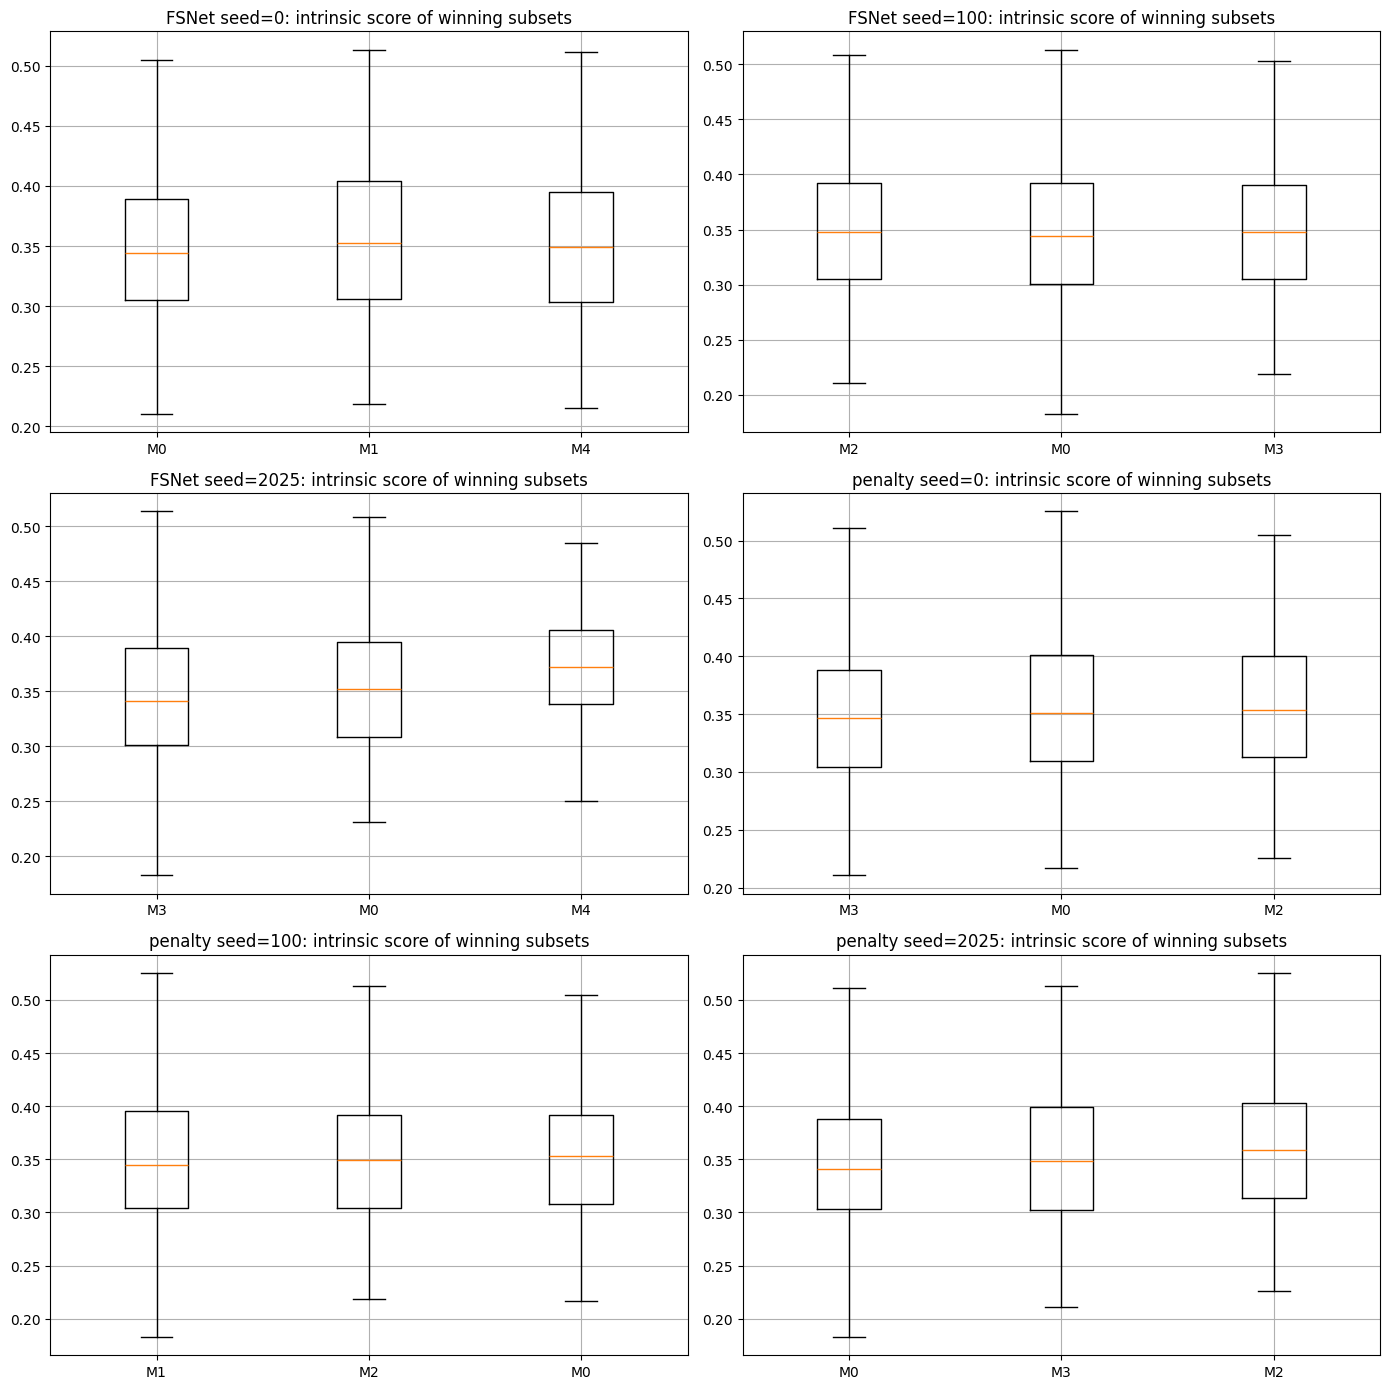

In [31]:
fig, axes = plt.subplots(3, 2, figsize=(14, 14))
axes = axes.ravel()
chosen_runs = [('FSNet', 0), ('FSNet', 100), ('FSNet', 2025), ('penalty', 0), ('penalty', 100), ('penalty', 2025)]

for ax, (method, seed) in zip(axes, chosen_runs):
        rr = next(r for r in run_results if r['method'] == method and r['seed'] == seed)
        top_members = list(np.argsort(rr['win_counts'])[::-1][:3])
        data = [intrinsic['intrinsic_score'][rr['winner'] == m] for m in top_members if np.any(rr['winner'] == m)]
        labels = [f'M{m}' for m in top_members if np.any(rr['winner'] == m)]
        ax.boxplot(data, tick_labels=labels, showfliers=False)
        ax.set_title(f'{method} seed={seed}: intrinsic score of winning subsets')

plt.tight_layout()
plt.show()


## 7. Why ensembling helps

In [32]:
gain_rows = []
for rr in run_results:
    high_intrinsic = qcut_mask(intrinsic['intrinsic_score'], q=0.75, hard=True)
    low_intrinsic = qcut_mask(intrinsic['intrinsic_score'], q=0.75, hard=False)
    high_disagree = qcut_mask(rr['disagreement_std'], q=0.75, hard=True)
    low_disagree = qcut_mask(rr['disagreement_std'], q=0.75, hard=False)
    high_repair = qcut_mask(rr['winner_move_l2'], q=0.75, hard=True)
    low_repair = qcut_mask(rr['winner_move_l2'], q=0.75, hard=False)

    for label, mask in [
        ('low_intrinsic', low_intrinsic),
        ('high_intrinsic', high_intrinsic),
        ('low_disagree', low_disagree),
        ('high_disagree', high_disagree),
        ('low_repair', low_repair),
        ('high_repair', high_repair),
    ]:
        gain_rows.append([
            rr['method'], rr['seed'], label,
            rr['ensemble_gain'][mask].mean(),
            rr['best_merit'][mask].mean(),
            rr['margin'][mask].mean(),
        ])

print('Ensemble gain partitioned by instance subset:')
print_table(['method', 'seed', 'subset', 'mean_gain', 'mean_ens_merit', 'mean_margin'], gain_rows)


Ensemble gain partitioned by instance subset:
method  | seed | subset         | mean_gain  | mean_ens_merit | mean_margin
--------+------+----------------+------------+----------------+------------
FSNet   | 0    | low_intrinsic  | 4.2231e+00 | 1.8595e+01     | 1.9928e+00 
FSNet   | 0    | high_intrinsic | 4.8692e+00 | 1.8915e+01     | 2.1298e+00 
FSNet   | 0    | low_disagree   | 1.5066e+00 | 1.8557e+01     | 1.7367e+00 
FSNet   | 0    | high_disagree  | 1.0041e+01 | 1.9469e+01     | 2.7581e+00 
FSNet   | 0    | low_repair     | 3.7677e+00 | 1.8111e+01     | 2.0569e+00 
FSNet   | 0    | high_repair    | 6.8166e+00 | 1.9908e+01     | 2.3030e+00 
FSNet   | 100  | low_intrinsic  | 4.1627e+00 | 1.8363e+01     | 2.1423e+00 
FSNet   | 100  | high_intrinsic | 4.7568e+00 | 1.9050e+01     | 2.4341e+00 
FSNet   | 100  | low_disagree   | 1.5907e+00 | 1.8641e+01     | 1.8843e+00 
FSNet   | 100  | high_disagree  | 1.1536e+01 | 1.9527e+01     | 2.9648e+00 
FSNet   | 100  | low_repair     | 5.5406e+

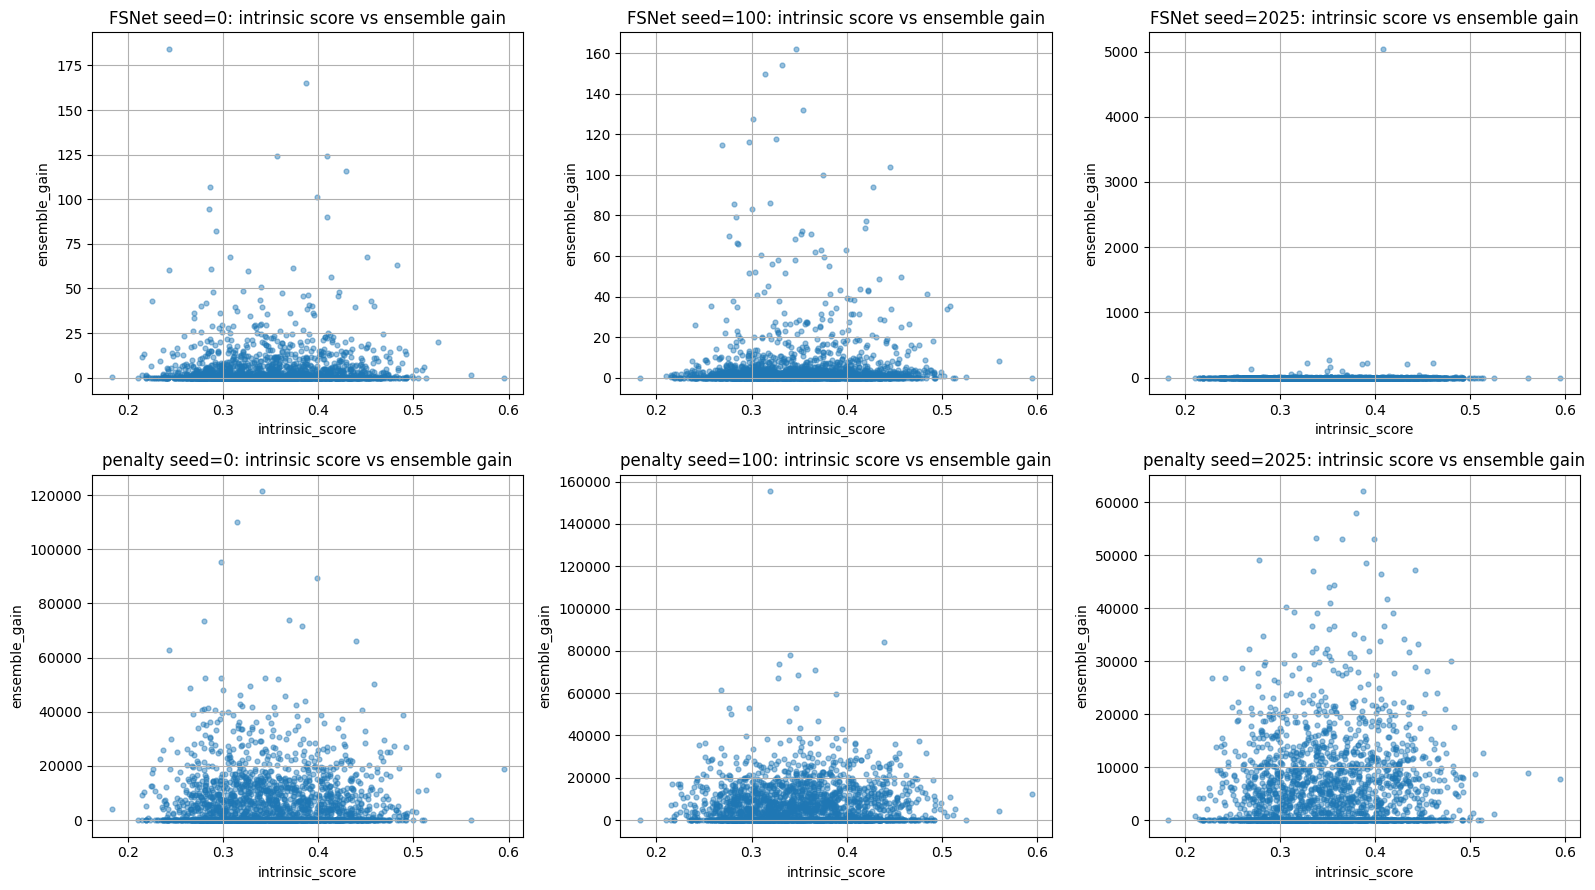

In [33]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
for ax, rr in zip(axes.ravel(), run_results):
    ax.scatter(intrinsic['intrinsic_score'], rr['ensemble_gain'], s=12, alpha=0.45)
    ax.set_title(f"{rr['method']} seed={rr['seed']}: intrinsic score vs ensemble gain")
    ax.set_xlabel('intrinsic_score')
    ax.set_ylabel('ensemble_gain')
plt.tight_layout()
plt.show()


## 8. Cross-seed stability summary

This section asks whether member *roles* are more stable than member indices.

In [34]:
stability_rows = []
for method in RUN_GROUPS:
    method_runs = [rr for rr in run_results if rr['method'] == method]
    for rr in method_runs:
        top_members = list(np.argsort(rr['win_counts'])[::-1][:2])
        for rank_idx, member in enumerate(top_members, start=1):
            mask = rr['winner'] == member
            stability_rows.append([
                method, rr['seed'], f'rank{rank_idx}', member,
                mask.sum(),
                intrinsic['intrinsic_score'][mask].mean(),
                rr['winner_move_l2'][mask].mean(),
                rr['disagreement_std'][mask].mean(),
                rr['best_merit'][mask].mean(),
            ])

print('Top-2 winner profile per run (to compare roles across seeds):')
print_table(['method', 'seed', 'rank', 'member', 'wins', 'intrinsic_score', 'winner_move', 'disagree_std', 'best_merit'], stability_rows)


Top-2 winner profile per run (to compare roles across seeds):
method  | seed | rank  | member | wins | intrinsic_score | winner_move | disagree_std | best_merit
--------+------+-------+--------+------+-----------------+-------------+--------------+-----------
FSNet   | 0    | rank1 | 0      | 1013 | 3.4904e-01      | 1.1220e-01  | 6.7846e+00   | 1.7849e+01
FSNet   | 0    | rank2 | 1      | 376  | 3.5576e-01      | 1.0437e-01  | 7.0762e+00   | 1.9256e+01
FSNet   | 100  | rank1 | 2      | 1010 | 3.5091e-01      | 1.1572e-01  | 7.7991e+00   | 1.7680e+01
FSNet   | 100  | rank2 | 0      | 713  | 3.4785e-01      | 1.6964e-01  | 7.7483e+00   | 1.9066e+01
FSNet   | 2025 | rank1 | 3      | 1397 | 3.4666e-01      | 2.9307e-01  | 2.1952e+01   | 1.7449e+01
FSNet   | 2025 | rank2 | 0      | 505  | 3.5463e-01      | 1.1677e-01  | 6.2816e+00   | 1.7028e+01
penalty | 0    | rank1 | 3      | 840  | 3.4830e-01      | 0.0000e+00  | 9.4815e+03   | 5.5163e+04
penalty | 0    | rank2 | 0      | 376  | 3.5609

## 9. Automatic conclusion draft

This cell gives a compact machine-generated readout. Use it as a starting point, not as the final word.

In [35]:
def summarize_method(method_name):
    method_runs = [rr for rr in run_results if rr['method'] == method_name]
    corr_gain = [spearman_corr(intrinsic['intrinsic_score'], rr['ensemble_gain']) for rr in method_runs]
    corr_merit = [spearman_corr(intrinsic['intrinsic_score'], rr['best_merit']) for rr in method_runs]
    high_vs_low_gain_ratio = []
    for rr in method_runs:
        hi = rr['ensemble_gain'][qcut_mask(intrinsic['intrinsic_score'], q=0.75, hard=True)].mean()
        lo = rr['ensemble_gain'][qcut_mask(intrinsic['intrinsic_score'], q=0.75, hard=False)].mean()
        high_vs_low_gain_ratio.append(hi / max(abs(lo), 1e-12))
    print(f'\n{method_name} summary')
    print('-' * (len(method_name) + 8))
    print(f"Average Spearman(intrinsic_score, best_merit): {safe_mean(corr_merit): .4f}")
    print(f"Average Spearman(intrinsic_score, ensemble_gain): {safe_mean(corr_gain): .4f}")
    print(f"Average high-hardness / low-hardness gain ratio: {safe_mean(high_vs_low_gain_ratio): .4f}")
    for rr in method_runs:
        top_member = int(np.argmax(rr['win_counts']))
        print(
            f"  seed={rr['seed']}: top winner=Member {top_member}, win share={rr['win_counts'][top_member] / rr['win_counts'].sum():.3f}, "
            f"best_single=Member {rr['best_single_member']}, mean_gain={rr['ensemble_gain'].mean():.4e}"
        )


print('Compact conclusion draft:')
print('1. Intrinsic hardness sanity:')
print(f"   oracle_eq_abs mean={intrinsic['oracle_eq_abs'].mean():.4e}, oracle_ineq_violation mean={intrinsic['oracle_ineq_violation'].mean():.4e}")
print('2. Method-level summaries:')
summarize_method('FSNet')
summarize_method('penalty')

print('\n3. Interpretation prompts:')
print('   - If intrinsic_score correlates with best_merit, intrinsically hard instances are also hard for the method.')
print('   - If intrinsic_score correlates with ensemble_gain, ensembling helps more on intrinsically hard instances.')
print('   - If top-winning member profiles look similar across seeds but member indices differ, roles are more stable than identities.')
print('   - If FSNet winner_move_l2 and repair_gain align with intrinsic_score, FSNet specializes partly through repair dynamics.')


Compact conclusion draft:
1. Intrinsic hardness sanity:
   oracle_eq_abs mean=7.5840e-14, oracle_ineq_violation mean=3.5020e-09
2. Method-level summaries:

FSNet summary
-------------
Average Spearman(intrinsic_score, best_merit):  0.1252
Average Spearman(intrinsic_score, ensemble_gain):  0.0435
Average high-hardness / low-hardness gain ratio:  8.3540
  seed=0: top winner=Member 0, win share=0.506, best_single=Member 0, mean_gain=4.2546e+00
  seed=100: top winner=Member 2, win share=0.505, best_single=Member 0, mean_gain=4.6341e+00
  seed=2025: top winner=Member 3, win share=0.699, best_single=Member 3, mean_gain=3.9843e+00

penalty summary
---------------
Average Spearman(intrinsic_score, best_merit):  0.1240
Average Spearman(intrinsic_score, ensemble_gain):  0.0282
Average high-hardness / low-hardness gain ratio:  1.0778
  seed=0: top winner=Member 3, win share=0.420, best_single=Member 3, mean_gain=6.6935e+03
  seed=100: top winner=Member 1, win share=0.349, best_single=Member 1, me

## 10. FSNet repair-basin specialization

These cells test the stronger hypothesis directly: different FSNet members may act as different *initializers* for the repair operator, and the ensemble helps most when repair changes the competitive order among members.


In [36]:
fsnet_runs = [rr for rr in run_results if rr['method'] == 'FSNet']

basin_rows = []
for rr in fsnet_runs:
    raw_merit = rr['member_arrays']['raw_merit']
    final_merit = rr['member_arrays']['final_merit']
    repair_gain = rr['member_arrays']['repair_gain']
    move_l2 = rr['member_arrays']['move_l2']

    raw_best = raw_merit.argmin(axis=0)
    final_best = final_merit.argmin(axis=0)
    raw_sorted = np.sort(raw_merit, axis=0)
    raw_margin = raw_sorted[1] - raw_sorted[0]
    raw_disagree_std = raw_merit.std(axis=0)
    repair_gain_std = repair_gain.std(axis=0)
    move_std = move_l2.std(axis=0)
    disagree_ratio = rr['disagreement_std'] / np.maximum(raw_disagree_std, 1e-12)

    high_gain = qcut_mask(rr['ensemble_gain'], q=0.75, hard=True)
    low_gain = qcut_mask(rr['ensemble_gain'], q=0.75, hard=False)

    basin_rows.append([
        rr['seed'],
        np.mean(raw_best != final_best),
        np.mean((raw_best != final_best)[high_gain]),
        np.mean((raw_best != final_best)[low_gain]),
        spearman_corr(raw_disagree_std, rr['ensemble_gain']),
        spearman_corr(repair_gain_std, rr['ensemble_gain']),
        spearman_corr(move_std, rr['ensemble_gain']),
        spearman_corr(raw_margin, rr['ensemble_gain']),
        safe_mean(disagree_ratio),
        raw_disagree_std.mean(),
        rr['disagreement_std'].mean(),
    ])

print('FSNet basin-sensitivity summary:')
print_table(
    ['seed', 'repair_flip_rate', 'flip_rate_high_gain', 'flip_rate_low_gain', 'rho(raw_disagree,gain)', 'rho(repair_gain_std,gain)', 'rho(move_std,gain)', 'rho(raw_margin,gain)', 'mean_final/raw_disagree', 'raw_disagree_mean', 'final_disagree_mean'],
    basin_rows,
)


FSNet basin-sensitivity summary:
seed | repair_flip_rate | flip_rate_high_gain | flip_rate_low_gain | rho(raw_disagree,gain) | rho(repair_gain_std,gain) | rho(move_std,gain) | rho(raw_margin,gain) | mean_final/raw_disagree | raw_disagree_mean | final_disagree_mean
-----+------------------+---------------------+--------------------+------------------------+---------------------------+--------------------+----------------------+-------------------------+-------------------+--------------------
0    | 7.5400e-01       | 7.3600e-01          | 7.9368e-01         | 7.5000e-02             | 7.4965e-02                | 1.9374e-01         | 5.3889e-02           | 2.0616e-04              | 4.0252e+04        | 7.3665e+00         
100  | 8.1150e-01       | 6.5600e-01          | 9.9860e-01         | 2.2036e-01             | 2.2030e-01                | 3.2792e-01         | 5.4826e-03           | 1.2163e-04              | 7.3529e+04        | 8.1184e+00         
2025 | 9.1750e-01       | 7.1400e-01   

In [37]:
member_role_rows = []
pairwise_rows = []

for rr in fsnet_runs:
    raw_merit = rr['member_arrays']['raw_merit']
    final_merit = rr['member_arrays']['final_merit']
    repair_gain = rr['member_arrays']['repair_gain']
    move_l2 = rr['member_arrays']['move_l2']
    raw_best = raw_merit.argmin(axis=0)
    final_best = final_merit.argmin(axis=0)
    n_members = raw_merit.shape[0]

    for m in range(n_members):
        raw_mask = raw_best == m
        final_mask = final_best == m
        promoted_mask = final_mask & (raw_best != m)
        demoted_mask = raw_mask & (final_best != m)
        member_role_rows.append([
            rr['seed'],
            m,
            int(raw_mask.sum()),
            int(final_mask.sum()),
            int(promoted_mask.sum()),
            int(demoted_mask.sum()),
            repair_gain[m].mean(),
            repair_gain[m, final_mask].mean() if final_mask.any() else np.nan,
            move_l2[m].mean(),
            move_l2[m, final_mask].mean() if final_mask.any() else np.nan,
            final_merit[m].mean(),
        ])

    top2 = list(np.argsort(rr['win_counts'])[::-1][:2])
    if len(top2) < 2:
        continue
    a, b = top2
    for label, winner_member, other_member in [('rank1_wins', a, b), ('rank2_wins', b, a)]:
        mask = final_best == winner_member
        if not mask.any():
            continue
        pairwise_rows.append([
            rr['seed'],
            label,
            winner_member,
            other_member,
            int(mask.sum()),
            raw_merit[winner_member, mask].mean(),
            raw_merit[other_member, mask].mean(),
            final_merit[winner_member, mask].mean(),
            final_merit[other_member, mask].mean(),
            repair_gain[winner_member, mask].mean(),
            repair_gain[other_member, mask].mean(),
            move_l2[winner_member, mask].mean(),
            move_l2[other_member, mask].mean(),
            np.mean(raw_best[mask] == winner_member),
        ])

print('FSNet member promotion/demotion summary:')
print_table(
    ['seed', 'member', 'raw_wins', 'final_wins', 'promoted_to_win', 'demoted_after_raw_win', 'mean_repair_gain', 'repair_gain_on_final_wins', 'mean_move', 'move_on_final_wins', 'mean_final_merit'],
    member_role_rows,
)

print('\nTop-2 member pairwise comparison on the subsets they end up winning:')
print_table(
    ['seed', 'subset', 'winner_member', 'other_member', 'count', 'winner_raw_merit', 'other_raw_merit', 'winner_final_merit', 'other_final_merit', 'winner_repair_gain', 'other_repair_gain', 'winner_move', 'other_move', 'winner_was_raw_best_frac'],
    pairwise_rows,
)


FSNet member promotion/demotion summary:
seed | member | raw_wins | final_wins | promoted_to_win | demoted_after_raw_win | mean_repair_gain | repair_gain_on_final_wins | mean_move  | move_on_final_wins | mean_final_merit
-----+--------+----------+------------+-----------------+-----------------------+------------------+---------------------------+------------+--------------------+-----------------
0    | 0      | 316      | 1013       | 804             | 107                   | 2.8677e+05       | 2.7159e+05                | 1.2821e-01 | 1.1220e-01         | 2.3051e+01      
0    | 1      | 572      | 376        | 235             | 431                   | 2.7066e+05       | 2.5962e+05                | 1.1953e-01 | 1.0437e-01         | 2.5150e+01      
0    | 2      | 565      | 3          | 2               | 564                   | 2.6853e+05       | 2.2844e+05                | 1.1449e-01 | 9.3272e-02         | 3.1764e+01      
0    | 3      | 93       | 244        | 231             | 8

In [38]:
print('FSNet repair-basin interpretation guide:')
print('- High repair_flip_rate means repair often changes which member is best.')
print('- If flip_rate_high_gain > flip_rate_low_gain, the biggest ensemble gains are exactly the cases where repair changes the ranking.')
print('- If rho(raw_disagree,gain) and rho(repair_gain_std,gain) are positive, gain is driven by basin sensitivity more than by static raw predictions.')
print('- Members with many promoted_to_win cases are not just strong raw predictors; they become strong after repair.')
print('- In the pairwise table, a low winner_was_raw_best_frac means the eventual winner often was not the best raw member before repair.')


FSNet repair-basin interpretation guide:
- High repair_flip_rate means repair often changes which member is best.
- If flip_rate_high_gain > flip_rate_low_gain, the biggest ensemble gains are exactly the cases where repair changes the ranking.
- If rho(raw_disagree,gain) and rho(repair_gain_std,gain) are positive, gain is driven by basin sensitivity more than by static raw predictions.
- Members with many promoted_to_win cases are not just strong raw predictors; they become strong after repair.
- In the pairwise table, a low winner_was_raw_best_frac means the eventual winner often was not the best raw member before repair.


## 11. Raw-vs-final geometry across FSNet members

This section captures actual raw and repaired predictions for the FSNet members so we can test a more geometric version of the basin story: do members start far apart, get pulled closer by repair, and still keep enough final separation on high-gain instances for the ensemble to matter?


In [39]:
def evaluate_member_run_with_traj(model, evaluator, dataset, method, batch_size=256):
    loader = torch.utils.data.DataLoader(dataset, batch_size=batch_size, shuffle=False)
    out = {
        'raw_obj': [], 'raw_eq': [], 'raw_ineq': [], 'raw_merit': [],
        'final_obj': [], 'final_eq': [], 'final_ineq': [], 'final_merit': [],
        'move_l2': [], 'repair_gain': [],
        'Y_raw': [], 'Y_final': [],
    }

    for X_batch, _Y_true in loader:
        X_batch = X_batch.to(DEVICE)
        with torch.no_grad():
            Y_raw = model(X_batch)
            Y_raw_scaled = evaluator.opt_problem.scale(Y_raw)
            Y_final = evaluator._post_process_predictions(X_batch, Y_raw_scaled)

            raw_obj = evaluator.opt_problem.obj_fn(Y_raw_scaled)
            raw_eq = evaluator.opt_problem.eq_resid(X_batch, Y_raw_scaled).abs().sum(dim=1)
            raw_ineq = evaluator.opt_problem.ineq_resid(X_batch, Y_raw_scaled).abs().sum(dim=1)
            raw_merit = raw_obj + MERIT_EQ_WEIGHT * raw_eq + MERIT_INEQ_WEIGHT * raw_ineq

            final_obj = evaluator.opt_problem.obj_fn(Y_final)
            final_eq = evaluator.opt_problem.eq_resid(X_batch, Y_final).abs().sum(dim=1)
            final_ineq = evaluator.opt_problem.ineq_resid(X_batch, Y_final).abs().sum(dim=1)
            final_merit = final_obj + MERIT_EQ_WEIGHT * final_eq + MERIT_INEQ_WEIGHT * final_ineq

            move_l2 = torch.linalg.norm(Y_final - Y_raw_scaled, dim=1)
            repair_gain = raw_merit - final_merit

        for k, v in [
            ('raw_obj', raw_obj), ('raw_eq', raw_eq), ('raw_ineq', raw_ineq), ('raw_merit', raw_merit),
            ('final_obj', final_obj), ('final_eq', final_eq), ('final_ineq', final_ineq), ('final_merit', final_merit),
            ('move_l2', move_l2), ('repair_gain', repair_gain), ('Y_raw', Y_raw_scaled), ('Y_final', Y_final),
        ]:
            out[k].append(v.detach().cpu().numpy())

    return {k: np.concatenate(v) for k, v in out.items()}


def mean_pairwise_l2(preds):
    # preds: (M, N, D) -> (N,)
    m = preds.shape[0]
    vals = []
    for i in range(m):
        for j in range(i + 1, m):
            vals.append(np.linalg.norm(preds[i] - preds[j], axis=1))
    return np.mean(np.stack(vals, axis=0), axis=0)


def load_fsnet_traj_result(seed, run_dir):
    ckpts = resolve_checkpoints(run_dir)
    first = torch.load(ckpts[0], map_location='cpu', weights_only=False)
    cfg = dict(first['config'])
    cfg['ensemble_post'] = 'post'
    cfg['ensemble_agg'] = 'best_merit'
    cfg['_eval_only'] = True
    problem, _ = load_instance(cfg)
    evaluator = Evaluator(problem, 'FSNet', cfg)

    member_out = []
    for ckpt in ckpts:
        model, _ = load_single_model(ckpt, problem)
        model.eval()
        member_out.append(evaluate_member_run_with_traj(model, evaluator, problem.test_dataset, 'FSNet', batch_size=BATCH_SIZE))

    arrays = {name: np.stack([m[name] for m in member_out], axis=0) for name in member_out[0].keys()}
    winner = arrays['final_merit'].argmin(axis=0)
    best_merit = arrays['final_merit'].min(axis=0)
    best_single_member = arrays['final_merit'].mean(axis=1).argmin()
    best_single_arr = arrays['final_merit'][best_single_member]
    ensemble_gain = best_single_arr - best_merit
    return {
        'seed': seed,
        'winner': winner,
        'best_single_member': int(best_single_member),
        'ensemble_gain': ensemble_gain,
        'arrays': arrays,
    }


fsnet_traj_results = []
for seed, run_dir in RUN_GROUPS['FSNet'].items():
    print(f'Loading FSNet trajectories for seed={seed} ...')
    fsnet_traj_results.append(load_fsnet_traj_result(seed, run_dir))

print(f'Collected trajectory-rich results for {len(fsnet_traj_results)} FSNet runs.')


Loading FSNet trajectories for seed=0 ...
Loading FSNet trajectories for seed=100 ...
Loading FSNet trajectories for seed=2025 ...
Collected trajectory-rich results for 3 FSNet runs.


In [40]:
geometry_rows = []
winner_geom_rows = []

for rr in fsnet_traj_results:
    arr = rr['arrays']
    raw_pw = mean_pairwise_l2(arr['Y_raw'])
    final_pw = mean_pairwise_l2(arr['Y_final'])
    contraction = raw_pw - final_pw
    hi_gain = qcut_mask(rr['ensemble_gain'], q=0.75, hard=True)
    lo_gain = qcut_mask(rr['ensemble_gain'], q=0.75, hard=False)
    winner = rr['winner']

    geometry_rows.append([
        rr['seed'],
        raw_pw.mean(),
        final_pw.mean(),
        (final_pw / np.maximum(raw_pw, 1e-12)).mean(),
        raw_pw[hi_gain].mean(),
        final_pw[hi_gain].mean(),
        raw_pw[lo_gain].mean(),
        final_pw[lo_gain].mean(),
        spearman_corr(raw_pw, rr['ensemble_gain']),
        spearman_corr(final_pw, rr['ensemble_gain']),
        spearman_corr(contraction, rr['ensemble_gain']),
    ])

    top2 = list(np.argsort(np.bincount(winner, minlength=arr['Y_final'].shape[0]))[::-1][:2])
    if len(top2) >= 2:
        a, b = top2
        for label, m in [('rank1_wins', a), ('rank2_wins', b)]:
            mask = winner == m
            if not mask.any():
                continue
            other = b if m == a else a
            raw_ab = np.linalg.norm(arr['Y_raw'][m, mask] - arr['Y_raw'][other, mask], axis=1)
            final_ab = np.linalg.norm(arr['Y_final'][m, mask] - arr['Y_final'][other, mask], axis=1)
            winner_geom_rows.append([
                rr['seed'], label, m, other, int(mask.sum()),
                raw_ab.mean(), final_ab.mean(), (final_ab / np.maximum(raw_ab, 1e-12)).mean(),
                rr['ensemble_gain'][mask].mean(),
            ])

print('FSNet raw-vs-final member geometry:')
print_table(
    ['seed', 'mean_raw_pairwise_l2', 'mean_final_pairwise_l2', 'mean_final/raw', 'high_gain_raw_l2', 'high_gain_final_l2', 'low_gain_raw_l2', 'low_gain_final_l2', 'rho(raw_pw,gain)', 'rho(final_pw,gain)', 'rho(contraction,gain)'],
    geometry_rows,
)

print('\nTop-2 winner geometry on their own winning subsets:')
print_table(
    ['seed', 'subset', 'winner_member', 'other_member', 'count', 'raw_l2_between_top2', 'final_l2_between_top2', 'final/raw', 'mean_gain'],
    winner_geom_rows,
)


FSNet raw-vs-final member geometry:
seed | mean_raw_pairwise_l2 | mean_final_pairwise_l2 | mean_final/raw | high_gain_raw_l2 | high_gain_final_l2 | low_gain_raw_l2 | low_gain_final_l2 | rho(raw_pw,gain) | rho(final_pw,gain) | rho(contraction,gain)
-----+----------------------+------------------------+----------------+------------------+--------------------+-----------------+-------------------+------------------+--------------------+----------------------
0    | 1.1201e+01           | 1.1248e+01             | 1.0042e+00     | 1.1259e+01       | 1.1312e+01         | 1.1171e+01      | 1.1215e+01        | 1.9558e-01       | 2.0519e-01         | -1.8690e-01          
100  | 1.3763e+01           | 1.3813e+01             | 1.0037e+00     | 1.3846e+01       | 1.3906e+01         | 1.3754e+01      | 1.3802e+01        | 1.7015e-01       | 1.8882e-01         | -2.1253e-01          
2025 | 1.2026e+01           | 1.2085e+01             | 1.0049e+00     | 1.2048e+01       | 1.2105e+01         | 1.20

In [41]:
print('Geometry interpretation guide:')
print('- If mean_final_pairwise_l2 << mean_raw_pairwise_l2, repair strongly contracts member predictions overall.')
print('- If high-gain_final_l2 stays noticeably above low-gain_final_l2, members still land in more distinct repaired solutions on the cases where the ensemble matters most.')
print('- Positive rho(final_pw,gain) means final geometric separation, not just raw separation, is associated with ensemble benefit.')
print('- Positive rho(contraction,gain) means the amount of repair-induced movement/compression itself helps explain ensemble gain.')


Geometry interpretation guide:
- If mean_final_pairwise_l2 << mean_raw_pairwise_l2, repair strongly contracts member predictions overall.
- If high-gain_final_l2 stays noticeably above low-gain_final_l2, members still land in more distinct repaired solutions on the cases where the ensemble matters most.
- Positive rho(final_pw,gain) means final geometric separation, not just raw separation, is associated with ensemble benefit.
- Positive rho(contraction,gain) means the amount of repair-induced movement/compression itself helps explain ensemble gain.


## 12. FSNet subset discovery by ranking signature

Instead of asking only whether the ensemble helps on average, this section groups instances by the *ordering* of members on that instance. These ranking signatures are concrete candidate subsets where different members are particularly good.


In [ ]:
rank_subset_rows = []
winner_family_rows = []

traj_by_seed = {rr['seed']: rr for rr in fsnet_traj_results}

for rr in fsnet_runs:
    seed = rr['seed']
    raw_merit = rr['member_arrays']['raw_merit']
    final_merit = rr['member_arrays']['final_merit']
    raw_best = raw_merit.argmin(axis=0)
    final_best = final_merit.argmin(axis=0)
    traj = traj_by_seed[seed]
    final_pw = mean_pairwise_l2(traj['arrays']['Y_final'])

    signatures = [tuple(np.argsort(final_merit[:, i])) for i in range(final_merit.shape[1])]
    unique, counts = np.unique(np.array(signatures, dtype=object), return_counts=True)
    order = np.argsort(counts)[::-1]

    for idx in order[:6]:
        sig = unique[idx]
        mask = np.array([s == sig for s in signatures], dtype=bool)
        rank_subset_rows.append([
            seed,
            str(sig),
            int(mask.sum()),
            mask.mean(),
            int(sig[0]),
            int(sig[1]),
            np.mean(raw_best[mask] != final_best[mask]),
            rr['ensemble_gain'][mask].mean(),
            rr['disagreement_std'][mask].mean(),
            rr['winner_move_l2'][mask].mean(),
            intrinsic['intrinsic_score'][mask].mean(),
            intrinsic['oracle_obj'][mask].mean(),
            final_pw[mask].mean(),
        ])

    winners = np.unique(final_best)
    for winner_member in winners:
        mask = final_best == winner_member
        top2_counts = {}
        for sig in np.array(signatures, dtype=object)[mask]:
            key = str(sig[:2])
            top2_counts[key] = top2_counts.get(key, 0) + 1
        dominant_top2 = max(top2_counts.items(), key=lambda kv: kv[1])[0]
        winner_family_rows.append([
            seed,
            int(winner_member),
            int(mask.sum()),
            dominant_top2,
            max(top2_counts.values()) / mask.sum(),
            np.mean(raw_best[mask] != final_best[mask]),
            rr['ensemble_gain'][mask].mean(),
            rr['disagreement_std'][mask].mean(),
            rr['winner_move_l2'][mask].mean(),
            intrinsic['intrinsic_score'][mask].mean(),
            intrinsic['oracle_obj'][mask].mean(),
            final_pw[mask].mean(),
        ])

print('Top FSNet ranking-signature subsets per seed:')
print_table(
    ['seed', 'signature', 'count', 'share', 'winner', 'runner_up', 'flip_rate', 'mean_gain', 'disagree_std', 'winner_move', 'intrinsic_score', 'oracle_obj', 'final_pw_l2'],
    rank_subset_rows,
)

print('\nWinner-family summary (what kind of subsets each winner tends to own):')
print_table(
    ['seed', 'winner', 'wins', 'dominant_top2', 'dominant_share', 'flip_rate', 'mean_gain', 'disagree_std', 'winner_move', 'intrinsic_score', 'oracle_obj', 'final_pw_l2'],
    winner_family_rows,
)


In [ ]:
print('Ranking-signature interpretation guide:')
print('- Each signature is the member ordering from best final merit to worst final merit on that subset.')
print('- If a winner has one dominant top-2 signature, it mostly owns one coherent competitive regime.')
print('- High flip_rate means repair is essential for that subset, not just a small refinement.')
print('- High final_pw_l2 means members remain geometrically distinct even after repair on that subset.')
print('- Comparing winner_move, disagree_std, and oracle_obj across signatures helps describe what kind of instances each winner is best at.')
